In [1]:
import pandas as pd
import csv
import krippendorff
import numpy as np

In [ ]:
df = pd.read_csv('../Datasets/annotations.csv', delimiter=",", encoding='utf-8')
df.head()

In [ ]:
tag_cols = ['tag_tamara', 'tag_katja']
tags = df[tag_cols]


In [ ]:
unique_tag6 = pd.unique(df[tag_cols].values.ravel())
tag_to_code6 = {label: idx for idx, label in enumerate(unique_tag6)}

for col in tag_cols:
    df[col + '_6class'] = df[col].map(tag_to_code6)

data_6class = df[[col + '_6class' for col in tag_cols]].to_numpy().T
alpha_6class = krippendorff.alpha(reliability_data=data_6class, level_of_measurement='nominal')

In [ ]:
print("KA 6-class score: ", alpha_6class)

In [ ]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

for col in tag_cols:
    df[col + '_3class'] = df[col].map(mapping_3class)

unique_tag3 = pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel())
tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

for col in tag_cols:
    df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)

data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T
alpha_3class = krippendorff.alpha(reliability_data=data_3class, level_of_measurement="nominal")

In [ ]:
print("KA 3-class score: ", alpha_3class)

In [ ]:
#----Percentage of agreed-upon instances---#
def percent_agreement(rows):
    values = [val for val in rows if pd.notnull(val)]
    return int(len(set(values)) == 1)

agreement_6 = df[tag_cols].apply(percent_agreement, axis=1).mean()
agreement_3 = df[[col + '_3class' for col in tag_cols]].apply(percent_agreement, axis=1).mean()

In [ ]:
print("Agreement for a 6-class schema: ", (agreement_6 * 100))
print("Agreement for a 3-class schema: ", (agreement_3 * 100))

# Final tag distribution

In [ ]:
df['final_tag'] = df['final_tag'].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)
mapping_mistakes = {
'Negative.' : 'Negative',
'Postive':'Positive',
'Negatvie': 'Negative',
'N_Negative':'M_Negative',
'Negative ': 'Negative'
}
df['final_tag'] = df['final_tag'].map(mapping_mistakes).fillna(df['final_tag'])
df['final_tag'].unique()


In [ ]:
label6 = df['final_tag'].value_counts()
label6

In [ ]:
label_percentage = (label6 / label6.sum()) * 100
label_percentage 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette('pastel')

plt.figure(figsize=(10,6))
plt.pie(label_percentage, labels=label_percentage.index, colors=palette, autopct='%1.1f%%')
plt.title('Sentence label distribution - 6-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_6class.png', dpi=300)
plt.show()

In [ ]:
df['final_tag3'] = df['final_tag'].map(mapping_3class)
df['final_tag3'].unique()

In [ ]:
label3 = df['final_tag3'].value_counts()
label3

In [ ]:
sent_percentage = (label3 / label3.sum()) *100
sent_percentage

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(sent_percentage, labels=sent_percentage.index, colors=palette, startangle=90, autopct='%1.1f%%')
plt.title('Sentence label distribution - 3-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_3class.png', dpi=300)
plt.show()

## KA and ACC scores across the annotation process

In [2]:
scores = pd.read_csv("./Tables/Annotation_evaluation.csv", encoding='utf-8')
scores = scores.rename(columns={'pilot':'Phase', 'KA_6class':'6-class', 'KA_3class':'3-class'})
scores = scores.drop(columns=['ACC_6class', 'ACC_3class'])
scores

,Phase,6-class,3-class
0,main1,0.4814,0.5082
1,main2,0.5430,0.5735
2,pilot1,0.2566,0.2573
3,pilot2,0.3316,0.3899
4,pilot3,0.3715,0.3870
5,pilot4,0.4754,0.5012
6,pilot5,0.3060,0.3377
7,pilot6,0.4363,0.3749


In [3]:
scores = pd.melt(scores,
                 id_vars=['Phase'], 
                 value_vars=['6-class', '3-class'],
                 var_name='Scale', 
                 value_name='Alpha Score'
)

scores

,Phase,Scale,Alpha Score
0,main1,6-class,0.4814
1,main2,6-class,0.5430
2,pilot1,6-class,0.2566
3,pilot2,6-class,0.3316
4,pilot3,6-class,0.3715
5,pilot4,6-class,0.4754
6,pilot5,6-class,0.3060
7,pilot6,6-class,0.4363
8,main1,3-class,0.5082
9,main2,3-class,0.5735


In [8]:
scores['sort_key'] = scores['Phase'].apply(lambda x: 0 if 'pilot' in x else 1)
scores = scores.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)
scores

,Phase,Scale,Alpha Score
0,pilot1,6-class,0.2566
1,pilot2,6-class,0.3316
2,pilot3,6-class,0.3715
3,pilot4,6-class,0.4754
4,pilot5,6-class,0.3060
5,pilot6,6-class,0.4363
6,pilot1,3-class,0.2573
7,pilot2,3-class,0.3899
8,pilot3,3-class,0.3870
9,pilot4,3-class,0.5012


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

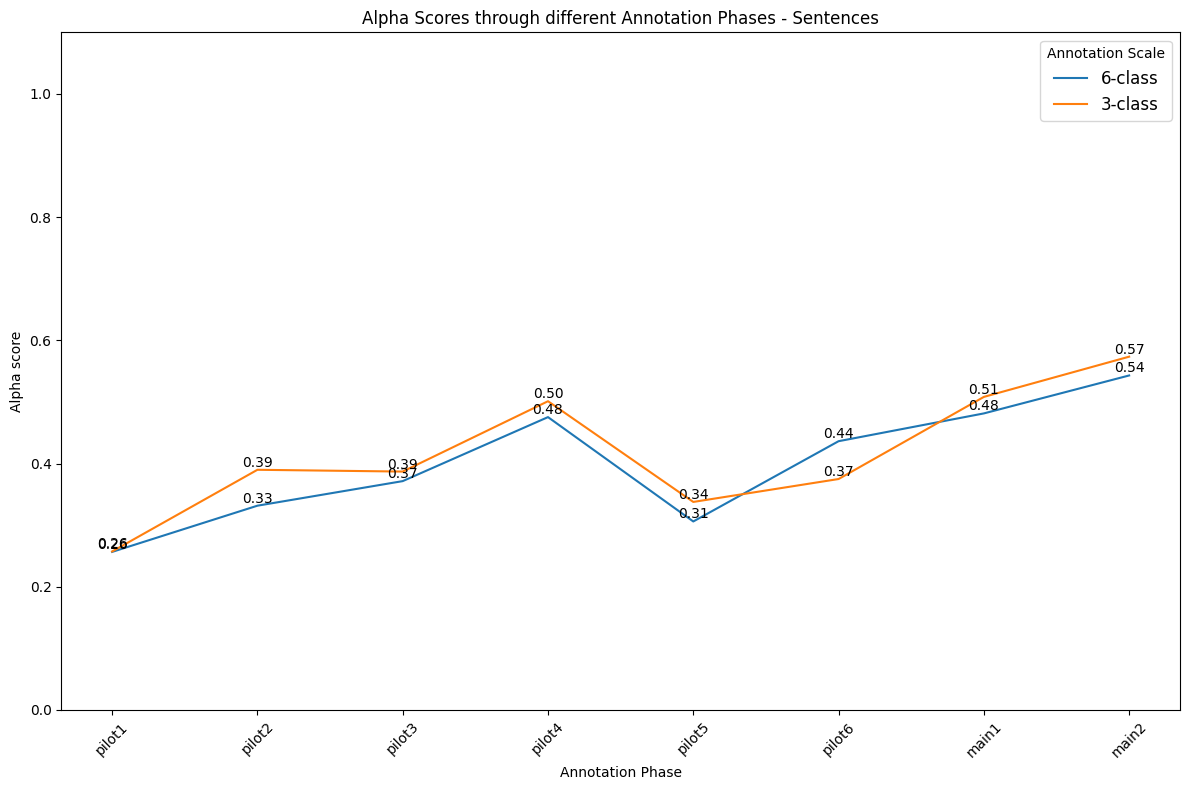

In [12]:
plt.figure(figsize=(12,8))
lineplot = sns.lineplot(data=scores, x="Phase", y="Alpha Score", hue='Scale', markers=True)

plt.title('Alpha Scores through different Annotation Phases - Sentences')
plt.xlabel("Annotation Phase")
plt.ylabel("Alpha score")
plt.legend(title="Annotation Scale", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../Figures/KA_Tracking.png', dpi=300)
plt.show()